<a href="https://colab.research.google.com/github/Yutyranus/Unet-Diceloss-vs-BCEloss/blob/main/U_Net_DiceLoss%26BCELoss_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **KHAI BÁO**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd '/content/drive/MyDrive/'

/content/drive/MyDrive


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision.datasets import OxfordIIITPet
from torchvision.transforms import functional as TF
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os
import cv2

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Device:", device)

Device: cuda


# **UPLOAD DATASET**

In [ ]:
class PetDataset(torch.utils.data.Dataset):
    def __init__(self, root='./data', image_size=128):
        self.dataset = OxfordIIITPet(root=root, download=True, target_types='segmentation')
        self.image_size = image_size
        self.transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, mask = self.dataset[idx]
        img = self.transform(img)

        mask = mask.resize((self.image_size, self.image_size), resample=Image.NEAREST)
        mask = np.array(mask)
        mask = np.where(mask==1, 1.0, 0.0)  # foreground=1, background=0
        mask = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)

        return img, mask

In [ ]:
train_ds = PetDataset(image_size=128)
train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=2)

100%|██████████| 792M/792M [01:01<00:00, 12.9MB/s]
100%|██████████| 19.2M/19.2M [00:02<00:00, 6.82MB/s]


In [ ]:
# train_ds = PetDataset()
# train_loader = DataLoader(train_ds, batch_size=2, shuffle=True)

# **DICE LOSS**

## **XÂY DỰNG MÔ HÌNH HUẤN LUYỆN**

In [ ]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.net(x)

class UNet(nn.Module):
    def __init__(self, n_channels=3, n_classes=1):
        super().__init__()
        self.inc = DoubleConv(n_channels, 32)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(32, 64))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(64, 128))
        self.down3 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(128, 256))
        self.up1 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.conv1 = DoubleConv(256, 128)
        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.conv2 = DoubleConv(128, 64)
        self.up3 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.conv3 = DoubleConv(64, 32)
        self.outc = nn.Conv2d(32, n_classes, 1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)

        x = self.up1(x4)
        x = self.conv1(torch.cat([x, x3], dim=1))
        x = self.up2(x)
        x = self.conv2(torch.cat([x, x2], dim=1))
        x = self.up3(x)
        x = self.conv3(torch.cat([x, x1], dim=1))
        logits = self.outc(x)
        return logits

In [ ]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super(DiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, preds, targets):
        preds = torch.sigmoid(preds)

        preds = preds.view(-1)
        targets = targets.to(torch.float32).view(-1)

        intersection = (preds * targets).sum()
        dice = (2. * intersection + self.smooth) / (preds.sum() + targets.sum() + self.smooth)

        return 1 - dice

In [ ]:
model = UNet().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

criterion = DiceLoss()

history_loss_dice = []

##**VÒNG HUẤN LUYỆN**

In [ ]:
for epoch in range(20):
    model.train()
    total_loss = 0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)

        preds = model(imgs)

        loss = criterion(preds, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    history_loss_dice.append(avg_loss)
    print(f"Epoch [{epoch+1}/20] - Dice Loss: {avg_loss:.4f}")

Epoch [1/20] - Dice Loss: 0.3605
Epoch [2/20] - Dice Loss: 0.2603
Epoch [3/20] - Dice Loss: 0.2246
Epoch [4/20] - Dice Loss: 0.2035
Epoch [5/20] - Dice Loss: 0.1913
Epoch [6/20] - Dice Loss: 0.1787
Epoch [7/20] - Dice Loss: 0.1717
Epoch [8/20] - Dice Loss: 0.1629
Epoch [9/20] - Dice Loss: 0.1578
Epoch [10/20] - Dice Loss: 0.1535
Epoch [11/20] - Dice Loss: 0.1449
Epoch [12/20] - Dice Loss: 0.1420
Epoch [13/20] - Dice Loss: 0.1371
Epoch [14/20] - Dice Loss: 0.1324
Epoch [15/20] - Dice Loss: 0.1259
Epoch [16/20] - Dice Loss: 0.1257
Epoch [17/20] - Dice Loss: 0.1239
Epoch [18/20] - Dice Loss: 0.1186
Epoch [19/20] - Dice Loss: 0.1149
Epoch [20/20] - Dice Loss: 0.1121


## **KẾT QUẢ**

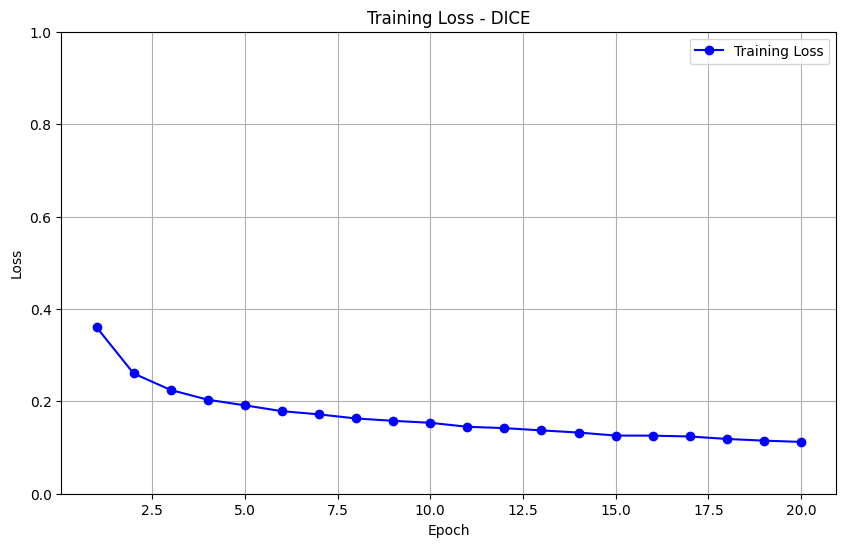

In [ ]:
plt.figure(figsize=(10, 6))
plt.ylim(0, 1.0)
plt.plot(range(1, len(history_loss_dice) + 1), history_loss_dice, marker='o', color='b', label='Training Loss')
plt.title('Training Loss - DICE')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.show()

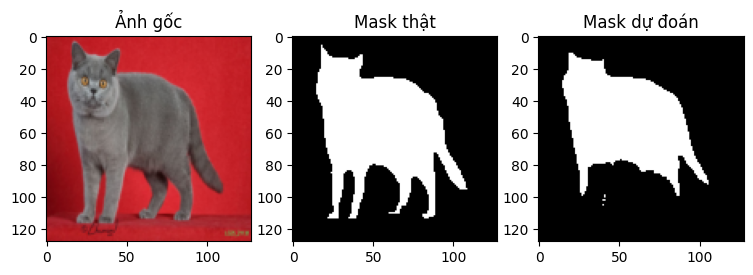

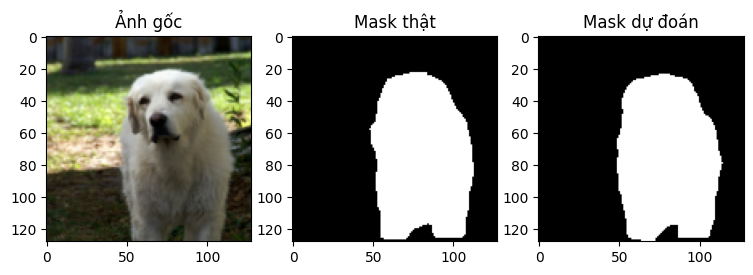

In [ ]:
model.eval()
imgs, masks = next(iter(train_loader))
with torch.no_grad():
    preds = model(imgs.to(device)).cpu()
for i in range(2):
    plt.figure(figsize=(9,3))
    plt.subplot(1,3,1); plt.imshow(np.transpose(imgs[i], (1,2,0))); plt.title('Ảnh gốc')
    plt.subplot(1,3,2); plt.imshow(masks[i][0], cmap='gray'); plt.title('Mask thật')
    plt.subplot(1,3,3); plt.imshow(preds[i][0]>0.5, cmap='gray'); plt.title('Mask dự đoán')
    plt.show()

# **BCE LOSS**

## **XÂY DỰNG MÔ HÌNH HUẤN LUYỆN**

In [ ]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.net(x)

class UNet(nn.Module):
    def __init__(self, n_channels=3, n_classes=1):
        super().__init__()
        self.inc = DoubleConv(n_channels, 32)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(32, 64))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(64, 128))
        self.down3 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(128, 256))
        self.up1 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.conv1 = DoubleConv(256, 128)
        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.conv2 = DoubleConv(128, 64)
        self.up3 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.conv3 = DoubleConv(64, 32)
        self.outc = nn.Conv2d(32, n_classes, 1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)

        x = self.up1(x4)
        x = self.conv1(torch.cat([x, x3], dim=1))
        x = self.up2(x)
        x = self.conv2(torch.cat([x, x2], dim=1))
        x = self.up3(x)
        x = self.conv3(torch.cat([x, x1], dim=1))
        logits = self.outc(x)
        return logits

In [ ]:
model = UNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()

## **VÒNG HUẤN LUYỆN**

In [ ]:
history_loss_bce = []

for epoch in range(20):
    model.train()
    total_loss = 0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        preds = model(imgs)
        loss = criterion(preds, masks)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    epoch_loss = total_loss / len(train_loader)
    history_loss_bce.append(epoch_loss)
    print(f"Epoch [{epoch+1}/20] - Loss: {total_loss/len(train_loader):.4f}")

Epoch [1/20] - Loss: 0.4438
Epoch [2/20] - Loss: 0.3286
Epoch [3/20] - Loss: 0.2879
Epoch [4/20] - Loss: 0.2630
Epoch [5/20] - Loss: 0.2434
Epoch [6/20] - Loss: 0.2294
Epoch [7/20] - Loss: 0.2199
Epoch [8/20] - Loss: 0.2041
Epoch [9/20] - Loss: 0.1972
Epoch [10/20] - Loss: 0.1851
Epoch [11/20] - Loss: 0.1744
Epoch [12/20] - Loss: 0.1669
Epoch [13/20] - Loss: 0.1627
Epoch [14/20] - Loss: 0.1505
Epoch [15/20] - Loss: 0.1427
Epoch [16/20] - Loss: 0.1334
Epoch [17/20] - Loss: 0.1290
Epoch [18/20] - Loss: 0.1217
Epoch [19/20] - Loss: 0.1131
Epoch [20/20] - Loss: 0.1099


## **KẾT QUẢ**

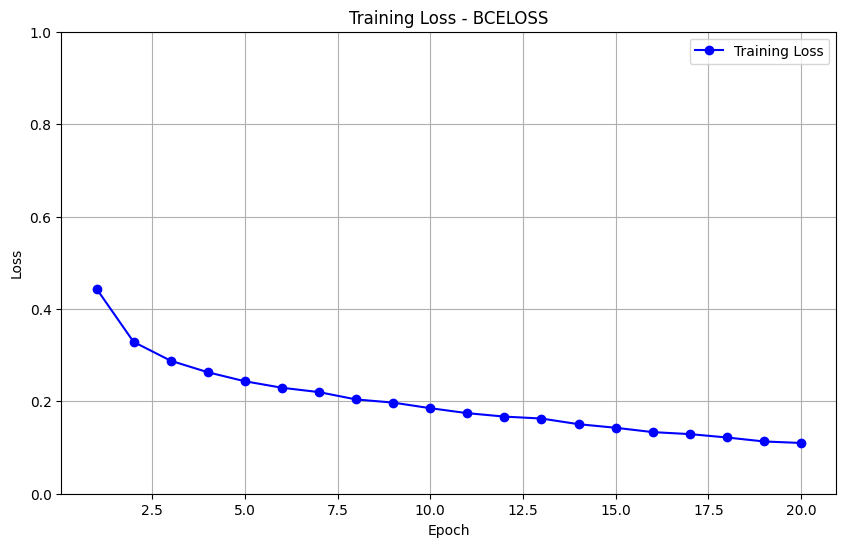

In [ ]:
plt.figure(figsize=(10, 6))
plt.ylim(0, 1.0)
plt.plot(range(1, len(history_loss_bce) + 1), history_loss_bce, marker='o', color='b', label='Training Loss')
plt.title('Training Loss - BCELOSS')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.show()

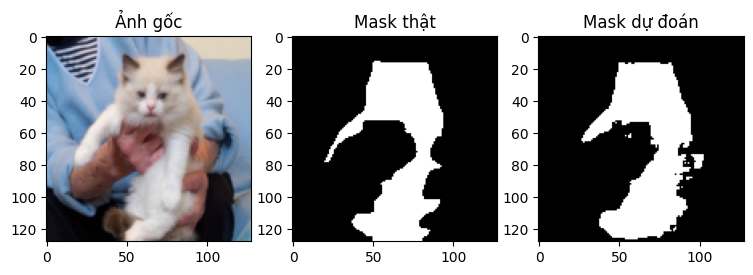

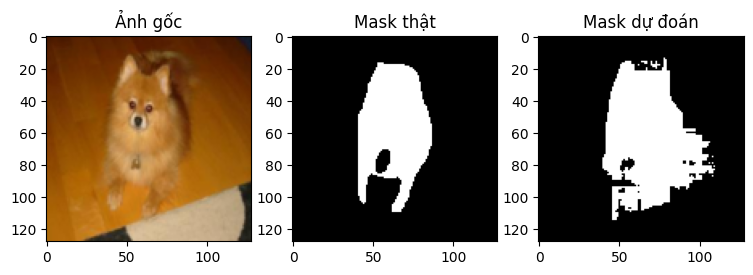

In [ ]:
model.eval()
imgs, masks = next(iter(train_loader))
with torch.no_grad():
    preds = model(imgs.to(device)).cpu()
for i in range(2):
    plt.figure(figsize=(9,3))
    plt.subplot(1,3,1); plt.imshow(np.transpose(imgs[i], (1,2,0))); plt.title('Ảnh gốc')
    plt.subplot(1,3,2); plt.imshow(masks[i][0], cmap='gray'); plt.title('Mask thật')
    plt.subplot(1,3,3); plt.imshow(preds[i][0]>0.5, cmap='gray'); plt.title('Mask dự đoán')
    plt.show()


# **DICELOSS + BCELOSS**

## **XÂY DỰNG MÔ HÌNH HUẤN LUYỆN**

In [ ]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.net(x)

class UNet(nn.Module):
    def __init__(self, n_channels=3, n_classes=1):
        super().__init__()
        self.inc = DoubleConv(n_channels, 32)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(32, 64))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(64, 128))
        self.down3 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(128, 256))
        self.up1 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.conv1 = DoubleConv(256, 128)
        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.conv2 = DoubleConv(128, 64)
        self.up3 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.conv3 = DoubleConv(64, 32)
        self.outc = nn.Conv2d(32, n_classes, 1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)

        x = self.up1(x4)
        x = self.conv1(torch.cat([x, x3], dim=1))
        x = self.up2(x)
        x = self.conv2(torch.cat([x, x2], dim=1))
        x = self.up3(x)
        x = self.conv3(torch.cat([x, x1], dim=1))
        logits = self.outc(x)
        return logits

In [ ]:
import torch
import torch.nn as nn

class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super(DiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, preds, targets):
        preds = torch.sigmoid(preds)
        preds = preds.view(-1)
        targets = targets.to(torch.float32).view(-1)

        intersection = (preds * targets).sum()
        dice = (2. * intersection + self.smooth) / (preds.sum() + targets.sum() + self.smooth)

        return 1 - dice

In [ ]:
model = UNet().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

criterion_bce = nn.BCEWithLogitsLoss()
criterion_dice = DiceLoss()

history_loss_bcedice = []

## **VÒNG HUẤN LUYỆN**

In [ ]:
for epoch in range(20):
    model.train()
    total_loss = 0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)

        preds = model(imgs)

        loss_bce = criterion_bce(preds, masks)
        loss_dice = criterion_dice(preds, masks)

        loss = loss_bce + loss_dice

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    epoch_loss = total_loss / len(train_loader)
    history_loss_bcedice.append(epoch_loss)
    print(f"Epoch [{epoch+1}/20] - Total Loss: {epoch_loss:.4f}")

Epoch [1/20] - Total Loss: 0.9373
Epoch [2/20] - Total Loss: 0.7474
Epoch [3/20] - Total Loss: 0.6299
Epoch [4/20] - Total Loss: 0.5700
Epoch [5/20] - Total Loss: 0.5072
Epoch [6/20] - Total Loss: 0.4743
Epoch [7/20] - Total Loss: 0.4515
Epoch [8/20] - Total Loss: 0.4220
Epoch [9/20] - Total Loss: 0.4030
Epoch [10/20] - Total Loss: 0.3849
Epoch [11/20] - Total Loss: 0.3736
Epoch [12/20] - Total Loss: 0.3488
Epoch [13/20] - Total Loss: 0.3357
Epoch [14/20] - Total Loss: 0.3219
Epoch [15/20] - Total Loss: 0.3110
Epoch [16/20] - Total Loss: 0.2964
Epoch [17/20] - Total Loss: 0.2773
Epoch [18/20] - Total Loss: 0.2695
Epoch [19/20] - Total Loss: 0.2591
Epoch [20/20] - Total Loss: 0.2404


##**KẾT QUẢ**

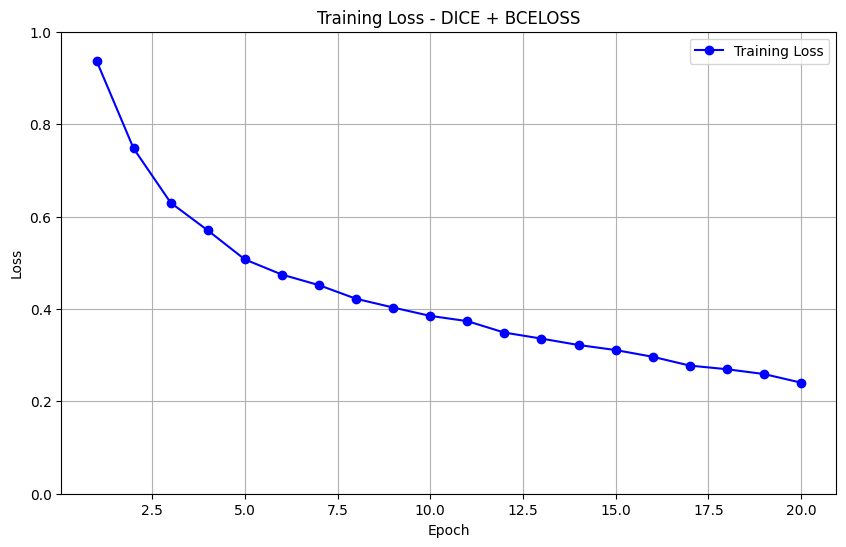

In [ ]:
plt.figure(figsize=(10, 6))
plt.ylim(0, 1.0)
plt.plot(range(1, len(history_loss_bcedice) + 1), history_loss_bcedice, marker='o', color='b', label='Training Loss')
plt.title('Training Loss - DICE + BCELOSS')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.show()

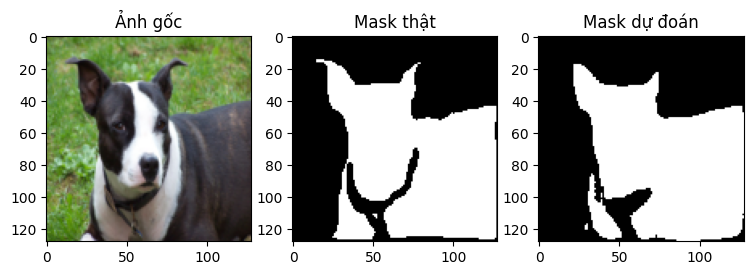

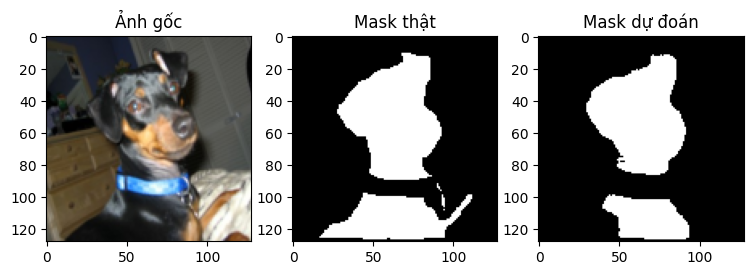

In [ ]:
model.eval()
imgs, masks = next(iter(train_loader))
with torch.no_grad():
    preds = model(imgs.to(device)).cpu()
for i in range(2):
    plt.figure(figsize=(9,3))
    plt.subplot(1,3,1); plt.imshow(np.transpose(imgs[i], (1,2,0))); plt.title('Ảnh gốc')
    plt.subplot(1,3,2); plt.imshow(masks[i][0], cmap='gray'); plt.title('Mask thật')
    plt.subplot(1,3,3); plt.imshow(preds[i][0]>0.5, cmap='gray'); plt.title('Mask dự đoán')
    plt.show()

nhận xét: khi kết hợp dice loss và bceloss theo tỉ lệ 1:1, ta được kết quả sau khi huấn luyện sát với tập dữ liệu gốc nhất